In [1]:
# ¿Qué tiempo medio en cola se espera el próximo mes en la red 800 de SSA y cuál es el riesgo de que la congestión aumente?

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")

activity_dir = Path("..")
data_dir = activity_dir / "data"
submission_dir = activity_dir / "submission"

In [2]:
# Las fuentes separan el resultado de congestión de sus señales operativas; se conservan ambas para que el pronóstico no dependa de una variable inventada.

speed = pd.read_csv(data_dir / "ssa_800_average_speed_to_answer.csv.gz")
workload = pd.read_csv(data_dir / "ssa_800_call_volume_and_busy_rate.csv.gz")

speed.columns = speed.columns.str.strip()
workload.columns = workload.columns.str.strip()

speed.head(3), workload.head(3)

(   FISCAL YEAR     MONTH AVERAGE SPEED TO ANSWER (SECONDS)
 0         2007   OCTOBER                               263
 1         2007  NOVEMBER                               334
 2         2007  DECEMBER                               369,
    FISCAL YEAR     MONTH  \
 0         2009   OCTOBER   
 1         2009  NOVEMBER   
 2         2009  DECEMBER   
 
   NUMBER OF CALLS OFFERED TO CUSTOMER SERVICE REPRESENTATIVES  \
 0                                          5,249,897            
 1                                          4,331,549            
 2                                          6,323,839            
 
   NUMBER OF BUSY CALLS CUSTOMER SERVICE REPRESENTATIVE BUSY RATE  
 0              577,341                                    11.00%  
 1              545,191                                    12.60%  
 2            1,801,396                                    28.50%  )

In [3]:
# El año fiscal de SSA empieza en octubre; reconstruir la fecha evita desplazar artificialmente los picos de congestión.

month_numbers = {
    "JANUARY": 1, "FEBRUARY": 2, "MARCH": 3, "APRIL": 4,
    "MAY": 5, "JUNE": 6, "JULY": 7, "AUGUST": 8,
    "SEPTEMBER": 9, "OCTOBER": 10, "NOVEMBER": 11, "DECEMBER": 12,
}

def fiscal_month_to_date(frame):
    frame = frame.copy()
    frame["MONTH"] = frame["MONTH"].str.strip().str.upper()
    frame = frame[frame["MONTH"].isin(month_numbers)].copy()
    frame["month_number"] = frame["MONTH"].map(month_numbers)
    frame["calendar_year"] = np.where(
        frame["month_number"] >= 10,
        frame["FISCAL YEAR"] - 1,
        frame["FISCAL YEAR"],
    )
    frame["date"] = pd.to_datetime(
        dict(year=frame["calendar_year"], month=frame["month_number"], day=1)
    )
    return frame

speed = fiscal_month_to_date(speed)
workload = fiscal_month_to_date(workload)

speed["average_speed_seconds"] = pd.to_numeric(
    speed["AVERAGE SPEED TO ANSWER (SECONDS)"].astype(str).str.replace(",", ""),
    errors="coerce",
)
workload["calls_offered"] = pd.to_numeric(
    workload["NUMBER OF CALLS OFFERED TO CUSTOMER SERVICE REPRESENTATIVES"].astype(str).str.replace(",", ""),
    errors="coerce",
)
workload["busy_rate"] = pd.to_numeric(
    workload["CUSTOMER SERVICE REPRESENTATIVE BUSY RATE"].astype(str).str.replace("%", ""),
    errors="coerce",
) / 100

congestion = speed[["date", "average_speed_seconds"]].merge(
    workload[["date", "calls_offered", "busy_rate"]],
    on="date",
    how="inner",
).dropna().sort_values("date").reset_index(drop=True)

congestion[["date", "average_speed_seconds", "calls_offered", "busy_rate"]].tail()

,date,average_speed_seconds,calls_offered,busy_rate
205,2025-11-01,512.0,3516965.0,0.002
206,2025-12-01,707.0,4718127.0,0.024
207,2026-01-01,664.0,5127423.0,0.012
208,2026-02-01,498.0,4439953.0,0.003
209,2026-03-01,421.0,4677380.0,0.000


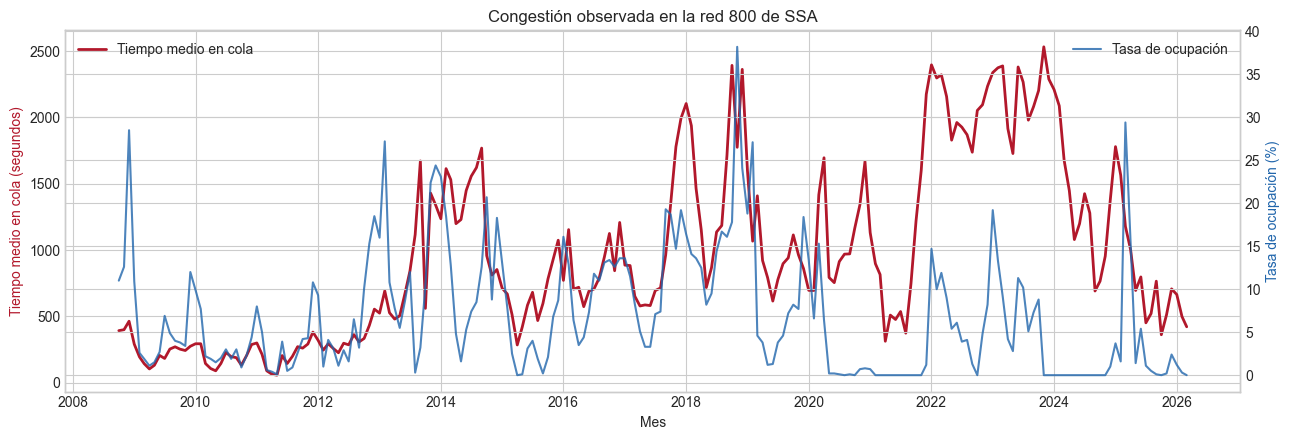

In [4]:
# La figura conecta la consecuencia para quien llama con las señales observables de carga; una relación no prueba por sí sola causalidad.

figure, axis_left = plt.subplots(figsize=(13, 4.5))
axis_right = axis_left.twinx()
axis_left.plot(
    congestion["date"], congestion["average_speed_seconds"],
    color="#b2182b", linewidth=2, label="Tiempo medio en cola",
)
axis_right.plot(
    congestion["date"], congestion["busy_rate"] * 100,
    color="#2166ac", linewidth=1.5, alpha=0.8, label="Tasa de ocupación",
)
axis_left.set_title("Congestión observada en la red 800 de SSA")
axis_left.set_xlabel("Mes")
axis_left.set_ylabel("Tiempo medio en cola (segundos)", color="#b2182b")
axis_right.set_ylabel("Tasa de ocupación (%)", color="#2166ac")
axis_left.legend(loc="upper left")
axis_right.legend(loc="upper right")
figure.tight_layout()
plt.show()

In [5]:
# El pronóstico de un mes usa solo el estado conocido al cerrar el mes anterior; así no se filtra información del futuro.

for column in ("average_speed_seconds", "calls_offered", "busy_rate"):
    congestion[f"{column}_lag_1"] = congestion[column].shift(1)

congestion["month"] = congestion["date"].dt.month.astype(str)
model_data = congestion.dropna().copy()

# La última anualidad observada se reserva íntegramente para evaluar un año de decisiones mensuales.
evaluation_months = 12
training = model_data.iloc[:-evaluation_months].copy()
evaluation = model_data.iloc[-evaluation_months:].copy()

features = [
    "average_speed_seconds_lag_1",
    "calls_offered_lag_1",
    "busy_rate_lag_1",
    "month",
]
target = "average_speed_seconds"

training[["date", *features, target]].tail()

,date,average_speed_seconds_lag_1,calls_offered_lag_1,busy_rate_lag_1,month,average_speed_seconds
193,2024-11-01,765.0,4427324.0,0.000,11,954.0
194,2024-12-01,954.0,3914980.0,0.000,12,1379.0
195,2025-01-01,1379.0,4977088.0,0.010,1,1780.0
196,2025-02-01,1780.0,6075969.0,0.037,2,1565.0
197,2025-03-01,1565.0,5219658.0,0.016,3,1179.0


In [6]:
# La línea base estacional pregunta si el modelo aporta más que repetir el tiempo observado en el mismo mes del año anterior.

seasonal_history = dict(zip(congestion["date"], congestion["average_speed_seconds"]))
def seasonal_naive(date):
    return seasonal_history.get(date - pd.DateOffset(years=1), np.nan)

evaluation["seasonal_naive_seconds"] = evaluation["date"].map(seasonal_naive)

evaluation[["date", target, "seasonal_naive_seconds"]]

,date,average_speed_seconds,seasonal_naive_seconds
198,2025-04-01,1002.0,1448.0
199,2025-05-01,695.0,1079.0
200,2025-06-01,797.0,1199.0
201,2025-07-01,451.0,1425.0
202,2025-08-01,521.0,1279.0
203,2025-09-01,765.0,691.0
204,2025-10-01,361.0,765.0
205,2025-11-01,512.0,954.0
206,2025-12-01,707.0,1379.0
207,2026-01-01,664.0,1780.0


In [7]:
# La regresión regularizada conserva una explicación directa: el nivel previo, la demanda previa, la ocupación previa y el mes pueden anticipar la congestión.

numeric_features = features[:-1]
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("month", OneHotEncoder(handle_unknown="ignore"), ["month"]),
    ]
)
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regression", Ridge(alpha=5.0)),
])
model.fit(training[features], training[target])
evaluation["operational_forecast_seconds"] = model.predict(evaluation[features])

evaluation[["date", target, "seasonal_naive_seconds", "operational_forecast_seconds"]]

,date,average_speed_seconds,seasonal_naive_seconds,operational_forecast_seconds
198,2025-04-01,1002.0,1448.0,1044.283423
199,2025-05-01,695.0,1079.0,899.912616
200,2025-06-01,797.0,1199.0,795.916704
201,2025-07-01,451.0,1425.0,867.850565
202,2025-08-01,521.0,1279.0,465.936907
203,2025-09-01,765.0,691.0,600.661090
204,2025-10-01,361.0,765.0,786.019873
205,2025-11-01,512.0,954.0,529.591689
206,2025-12-01,707.0,1379.0,716.886153
207,2026-01-01,664.0,1780.0,641.593945


/Volumes/GitHub/classroom-vibecoding/.venv/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Volumes/GitHub/classroom-vibecoding/.venv/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


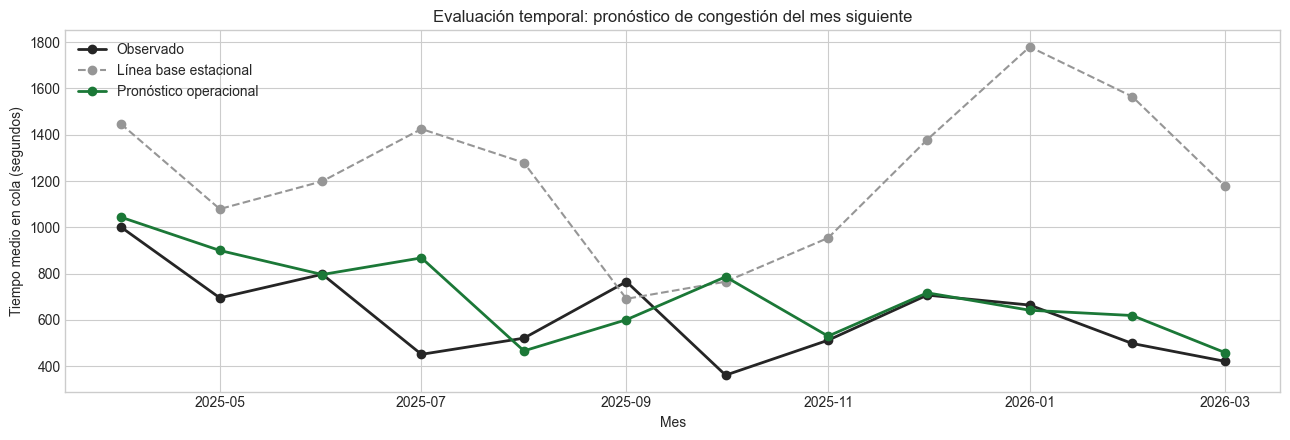

,model,mae_seconds,rmse_seconds
0,Línea base estacional,624.8,695.5
1,Regresión operacional rezagada,126.5,192.6


In [8]:
# La comparación temporal decide si las señales operativas mejoran una base que respeta la estacionalidad.

metrics = pd.DataFrame([
    {
        "model": "Línea base estacional",
        "mae_seconds": mean_absolute_error(evaluation[target], evaluation["seasonal_naive_seconds"]),
        "rmse_seconds": mean_squared_error(evaluation[target], evaluation["seasonal_naive_seconds"], squared=False),
    },
    {
        "model": "Regresión operacional rezagada",
        "mae_seconds": mean_absolute_error(evaluation[target], evaluation["operational_forecast_seconds"]),
        "rmse_seconds": mean_squared_error(evaluation[target], evaluation["operational_forecast_seconds"], squared=False),
    },
]).round(1)

figure, axis = plt.subplots(figsize=(13, 4.5))
axis.plot(evaluation["date"], evaluation[target], marker="o", linewidth=2, color="#252525", label="Observado")
axis.plot(evaluation["date"], evaluation["seasonal_naive_seconds"], marker="o", linestyle="--", color="#969696", label="Línea base estacional")
axis.plot(evaluation["date"], evaluation["operational_forecast_seconds"], marker="o", linewidth=2, color="#1b7837", label="Pronóstico operacional")
axis.set_title("Evaluación temporal: pronóstico de congestión del mes siguiente")
axis.set_xlabel("Mes")
axis.set_ylabel("Tiempo medio en cola (segundos)")
axis.legend()
figure.tight_layout()
plt.show()

metrics

In [9]:
# La evidencia deja disponible la respuesta, el contraste y los supuestos para discutir qué puede —y qué no puede— sostener el pronóstico.

forecast = evaluation[[
    "date", "average_speed_seconds", "calls_offered", "busy_rate",
    "seasonal_naive_seconds", "operational_forecast_seconds",
]].rename(columns={
    "average_speed_seconds": "observed_average_speed_seconds",
    "calls_offered": "observed_calls_offered",
    "busy_rate": "observed_busy_rate",
})

figure.savefig(submission_dir / "congestion_forecast.png", dpi=150, bbox_inches="tight")
forecast.to_csv(submission_dir / "congestion_forecast.csv", index=False)
metrics.to_csv(submission_dir / "model_metrics.csv", index=False)

assumptions = {
    "question": "What average queue time should be expected next month in SSA's 800 network?",
    "forecast_horizon": "One month ahead, evaluated for the final 12 observed months.",
    "target": "Monthly Average Speed to Answer in seconds.",
    "signals": "Prior-month queue time, calls offered, representative busy rate, and month of year.",
    "baseline": "Same month of the previous year.",
    "limitations": [
        "The data are aggregate monthly national observations, not individual calls.",
        "The model forecasts congestion; it does not estimate the number of agents or optimize staffing.",
        "A shock that changes operations can invalidate a model trained on previous months.",
    ],
}
(submission_dir / "model_assumptions.json").write_text(
    json.dumps(assumptions, indent=2) + "\n"
)

forecast.tail(), metrics

(          date  observed_average_speed_seconds  observed_calls_offered  \
 205 2025-11-01                           512.0               3516965.0   
 206 2025-12-01                           707.0               4718127.0   
 207 2026-01-01                           664.0               5127423.0   
 208 2026-02-01                           498.0               4439953.0   
 209 2026-03-01                           421.0               4677380.0   
 
      observed_busy_rate  seasonal_naive_seconds  operational_forecast_seconds  
 205               0.002                   954.0                    529.591689  
 206               0.024                  1379.0                    716.886153  
 207               0.012                  1780.0                    641.593945  
 208               0.003                  1565.0                    618.819867  
 209               0.000                  1179.0                    458.955560  ,
                             model  mae_seconds  rmse_seconds